# Stage 4. Dual-Path Feature Extraction

Notebook ini mengekstraksi dua jalur fitur komplementer, yaitu jalur biomarker warna hand-crafted yang interpretable dan jalur deep embedding dengan modul channel spatial attention. Kedua jalur diperiksa hubungannya dengan hemoglobin, lalu difusikan bersama demografi dan site token memakai modul fusion attention.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from configs import paths
from src import data, features

manifest = data.build_manifest(save=False)
print("manifest", manifest.shape)
print("device", "cuda" if torch.cuda.is_available() else "cpu")

Eyes-Defy Italy melewati 2 folder tanpa metadata atau file lengkap: [93, 95]
Eyes-Defy India melewati 1 folder tanpa metadata atau file lengkap: [7]
manifest (925, 13)
device cuda


## Handcrafted Color Features

Fitur warna hand-crafted mencakup statistik RGB, HSV, dan CIELAB, rasio terkait hemoglobin seperti HHR dan erythema index, entropy, brightness, serta tekstur gray level lokal. Fitur dihitung pada pixel valid hasil normalisasi Stage 2 agar konsisten dengan pipeline iluminasi.

In [2]:
handcrafted = features.extract_handcrafted_features(manifest)
print("handcrafted shape", handcrafted.shape)
handcrafted.head()

handcrafted shape (925, 28)


,uid,mean_r,mean_g,mean_b,mean_r_minus_g,hhr,hhr_hue,red_ratio,erythema_index,mean_h,...,std_a,mean_bb,std_bb,g1,g2,g3,g4,g5,entropy,brightness
0,cp_Image_001,168.110062,71.998177,55.138866,96.111885,2.334921,0.000000,0.569388,0.549217,0.024990,...,2.673850,157.526077,2.493710,9.665130,2.267070,2.126807,4.660628,98.829445,5.165405,98.829444
1,cp_Image_002,203.171036,114.263206,103.669220,88.907829,1.778097,0.063850,0.482473,0.348633,0.081113,...,4.564106,149.380600,5.366773,13.457112,6.308709,1.992362,6.964801,139.645462,6.114982,139.645462
2,cp_Image_005,180.510986,94.482193,93.170456,86.028793,1.910529,0.404294,0.490301,0.431189,0.408325,...,4.810320,145.219055,6.130230,15.978275,5.601491,2.998129,7.803643,120.065819,6.583554,120.065818
3,cp_Image_007,158.705414,92.965813,90.601707,65.739601,1.707137,0.180859,0.463681,0.438216,0.187282,...,4.015501,141.030182,3.130099,14.752156,8.110718,1.555804,7.917221,112.354401,5.978845,112.354404
4,cp_Image_009,194.622864,104.910561,104.654221,89.712303,1.855131,0.365299,0.481516,0.385720,0.367183,...,2.958255,144.263412,3.982683,22.137852,7.356232,4.097929,10.537005,131.708008,5.691372,131.708007


## Correlation with Hemoglobin

Fitur yang secara fisiologis berkaitan dengan penyerapan cahaya hemoglobin diperiksa hubungannya dengan kadar hemoglobin. Korelasi positif pada rasio kemerahan sesuai ekspektasi karena kepucatan konjungtiva berkurang seiring naiknya hemoglobin.

In [3]:
merged = manifest[["uid", "hb_gdl", "dataset"]].merge(handcrafted, on="uid")
candidate_columns = ["hhr", "mean_a", "mean_r_minus_g", "erythema_index", "red_ratio", "entropy"]
correlations = merged[["hb_gdl"] + candidate_columns].corr()["hb_gdl"].drop("hb_gdl")
print(correlations.sort_values(ascending=False).round(3).to_string())

hhr               0.285
erythema_index    0.257
mean_a            0.255
entropy           0.220
mean_r_minus_g    0.173
red_ratio         0.156


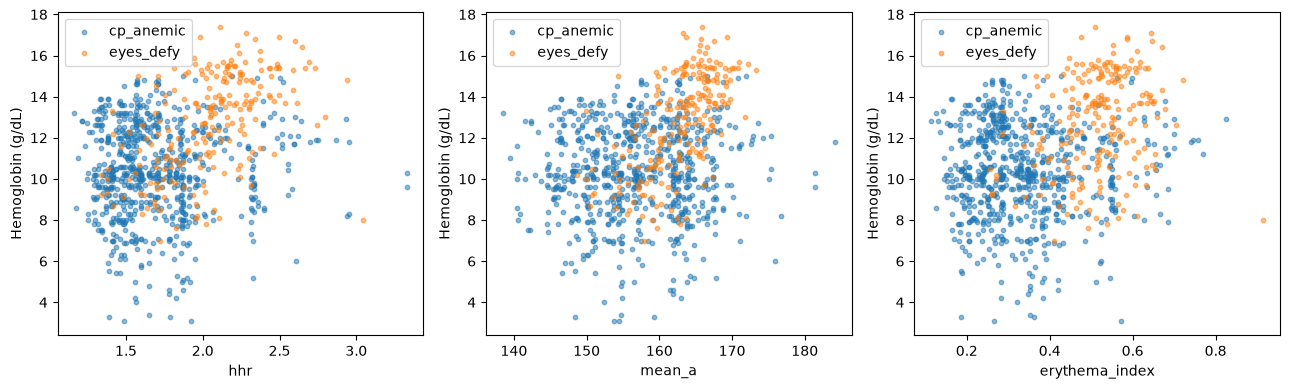

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
scatter_columns = ["hhr", "mean_a", "erythema_index"]
for ax, column in zip(axes, scatter_columns):
    for name, group in merged.groupby("dataset"):
        ax.scatter(group[column], group["hb_gdl"], s=10, alpha=0.5, label=name)
    ax.set_xlabel(column)
    ax.set_ylabel("Hemoglobin (g/dL)")
    ax.legend()
plt.tight_layout()
plt.show()

## Deep Embedding Extraction

Jalur deep embedding memakai ResNet18 pralatih ImageNet dengan modul channel spatial attention yang disisipkan setelah blok pertama untuk menonjolkan detail halus seperti pembuluh darah. Keluaran diproyeksikan menjadi vektor berdimensi 256.

In [5]:
backbone = features.EmbeddingBackbone()
deep_embeddings, uids = features.extract_deep_embeddings(manifest, model=backbone)
print("embeddings shape", deep_embeddings.shape)
print("order matches manifest", list(uids) == list(manifest["uid"]))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/praktikan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  2%|▏         | 768k/44.7M [00:00<00:05, 7.68MB/s]

 13%|█▎        | 5.62M/44.7M [00:00<00:01, 32.9MB/s]

 30%|██▉       | 13.4M/44.7M [00:00<00:00, 53.8MB/s]

...

 62%|██████▏   | 27.9M/44.7M [00:00<00:00, 66.1MB/s]

 79%|███████▉  | 35.2M/44.7M [00:00<00:00, 69.8MB/s]

 97%|█████████▋| 43.2M/44.7M [00:00<00:00, 74.3MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 64.7MB/s]

embeddings shape (925, 256)
order matches manifest True


## Fusion Attention Demonstration

Fitur hand-crafted yang distandarisasi, deep embedding, demografi, dan site token digabungkan menjadi satu vektor per sampel, lalu dilewatkan melalui modul fusion attention untuk menghasilkan representasi fusi berdimensi sama.

In [6]:
fusion_input = features.build_fusion_input(handcrafted, deep_embeddings, manifest)
print("fusion input shape", fusion_input.shape)

fusion_module = features.FusionAttention(feature_dim=fusion_input.shape[1])
with torch.no_grad():
    sample_batch = torch.from_numpy(fusion_input[:8]).float()
    fused_output = fusion_module(sample_batch)
print("fused output shape", tuple(fused_output.shape))

fusion input shape (925, 288)
fused output shape (8, 288)


## Save Features

Fitur hand-crafted dan deep embedding disimpan ke folder outputs untuk dipakai pelatihan model multi-task pada Stage 5.

In [7]:
saved_paths = features.save_features(handcrafted, deep_embeddings, uids)
print(saved_paths)

{'handcrafted': '/home/praktikan/projects/Azril/hemavision/outputs/handcrafted_features.csv', 'embeddings': '/home/praktikan/projects/Azril/hemavision/outputs/deep_embeddings.npy', 'uids': '/home/praktikan/projects/Azril/hemavision/outputs/deep_embeddings_uids.csv'}
